### PySpark Otomoto Demo 

Źródło danych: https://www.kaggle.com/datasets/szymoncyperski/car-sales-offers-from-otomotopl-2023 


In [1]:
import os
os.environ["JAVA_HOME"] = "/opt/homebrew/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home"

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import matplotlib.pyplot as plt

**Teoria:** Powyżej importujemy niezbędne biblioteki. `SparkSession` to główny punkt wejścia do funkcjonalności DataFrame i SQL w Sparku (od wersji 2.0). Moduł `functions` dostarcza wbudowane funkcje operujące na kolumnach, a `matplotlib.pyplot` posłuży nam do późniejszej wizualizacji danych.


`sc = spark.sparkContext` `sc.parallelize(data)` RDD, collect(), take()

In [2]:
spark = SparkSession.builder \
    .appName("Otomoto Demo") \
    .getOrCreate() # zapobiega duplikacji sesji, jesli dzialala sesja wczesniej to ja rozpozna albo zacznie od 0


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/18 09:45:49 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


**Teoria:** Tworzymy sesję Sparka. `builder` używa wzorca projektowego Builder do skonfigurowania sesji. `getOrCreate()` tworzy nową sesję lub pobiera istniejącą, co jest bezpieczne przy wielokrotnym uruchamianiu notatnika.


In [3]:
df = spark.read.option("header", True) \
    .option("delimiter", ";") \
    .option("inferSchema", False) \
    .csv("otomoto_offers_eng_23-04-2023.csv")


**Teoria:** Wczytywanie danych. Spark używa leniwego ewaluowania (lazy evaluation) - dane nie są fizycznie wczytywane w tym momencie, tworzony jest tylko plan wykonania (DAG). Ustawiamy `header=True` ponieważ nasz plik CSV ma nagłówki, oraz określamy separator jako średnik `;`.


In [4]:
df.show()

26/05/18 09:45:52 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+----------+-------------------+--------------------+------+--------+-----------------+------------------------+--------------------+---------------+--------+---------------------------+-------------+-------------+---------------+---------------+----------+-------------------+--------------+------+------------+-------------+---------------+---------------+---------+----------+---------------------+-----+--------------------+------------------------+----------+-----+---------------------------+------------+-----------+--------------------------+--------------------------+--------------+-------------+----------------------+----------------------------------+----------------------------+----------------------+---------------------+--------------+------------------------------------+-------------------+----------------+--------------+---------------+------------+----+-------------------+-------------+----------------+------------------+------------------+------------------+----------------

**Teoria:** `show()` to akcja (action), która uruchamia wykonanie obliczeń w Sparku. Dopiero teraz plik jest odczytywany, a wynik prezentowany na ekranie.


In [5]:
df.filter(F.col("vehicle_brand") == "Volvo").show()

+----------+-------------------+--------------------+------+--------+-----------------+------------------------+--------------------+---------------+--------+---------------------------+-------------+-------------+-------------+---------------+----------+-------------------+---------+------+------------+-------------+---------------+---------------+--------+----------+---------------------+-----+--------------------+------------------------+----------+-----+---------------------------+------------+-----------+--------------------------+--------------------------+--------------+-------------+----------------------+----------------------------------+----------------------------+----------------------+---------------------+--------------+------------------------------------+-------------------+----------------+--------------+---------------+------------+----+-------------------+-------------+----------------+------------------+------------------+------------------+-----------------+------

In [6]:
df = df.withColumn("price_num",
                   F.regexp_replace(F.col("price"), r"[^\d]", "").cast("double"))

df = df.withColumn("mileage_km",
                   F.regexp_replace(F.col("mileage"), r"[^\d]", "").cast("integer"))

df = df.withColumn("production_year_int",
                   F.regexp_replace(F.col("production_year"), r"[^\d]", "").cast("integer"))

df = df.withColumn("engine_cc",
                   F.regexp_replace(F.col("engine_displacement"), r"[^\d]", "").cast("integer"))

df = df.withColumn("power_hp",
                   F.regexp_replace(F.col("power"), r"[^\d]", "").cast("integer"))

df = df.withColumn("fuel_clean",
                   F.lower(F.trim(F.col("fuel_type"))))

In [7]:
df.select("vehicle_brand", "vehicle_model", "price_num", "mileage_km",
          "production_year_int", "engine_cc", "power_hp", "fuel_clean") \
  .show(10, truncate=False)

+-------------+-------------+---------+----------+-------------------+---------+--------+--------------+
|vehicle_brand|vehicle_model|price_num|mileage_km|production_year_int|engine_cc|power_hp|fuel_clean    |
+-------------+-------------+---------+----------+-------------------+---------+--------+--------------+
|Volvo        |V70          |23200.0  |304000    |2010               |15603    |109     |diesel        |
|Honda        |Accord       |16800.0  |236000    |2005               |19983    |155     |gasoline      |
|Mercedes-Benz|Klasa X      |249900.0 |73000     |2019               |29873    |258     |diesel        |
|Toyota       |Avensis      |16499.0  |220000    |2005               |17943    |129     |gasoline      |
|Ford         |C-MAX        |29900.0  |179058    |2012               |19973    |140     |diesel        |
|Peugeot      |208          |80900.0  |1         |2023               |11993    |75      |gasoline      |
|Kia          |Sportage     |74770.0  |100420    |2018 

**Teoria:** `select()` to transformacja, która działa jak w SQL - pozwala wybrać podzbiór kolumn. Zmniejsza to ilość przetwarzanych danych w dalszych krokach.


In [8]:
avg_brand = df.groupBy("vehicle_brand") \
              .agg(F.round(F.avg("price_num"), 2).alias("avg_price")) \
              .orderBy(F.col("avg_price").desc())

print("Średnia cena per marka")
avg_brand.show(20, truncate=False)

Średnia cena per marka


+-------------+----------+
|vehicle_brand|avg_price |
+-------------+----------+
|Lamborghini  |1281601.59|
|Ferrari      |1015648.41|
|McLaren      |866462.12 |
|Rolls-Royce  |762649.96 |
|Bentley      |657051.57 |
|Maybach      |575529.83 |
|Aston Martin |530891.29 |
|KTM          |389000.0  |
|Porsche      |363902.5  |
|Alpine       |352555.5  |
|RAM          |348905.66 |
|Geely        |346903.0  |
|BMW-ALPINA   |333006.94 |
|LEVC         |305776.0  |
|Skywell      |274743.33 |
|Maxus        |255052.59 |
|Tesla        |232544.92 |
|Caterham     |227550.0  |
|Land Rover   |200495.64 |
|Maserati     |197591.6  |
+-------------+----------+
only showing top 20 rows



In [9]:
fuel_count = df.groupBy("fuel_clean").count()
print("Liczba ogłoszeń wg rodzaju paliwa")
fuel_count.show()

Liczba ogłoszeń wg rodzaju paliwa
+--------------+------+
|    fuel_clean| count|
+--------------+------+
|      gasoline|101165|
|        diesel| 88624|
|gasoline + lpg|  7419|
|        hybrid|  7527|
|gasoline + cng|    96|
|      electric|  3373|
|      hydrogen|     1|
+--------------+------+



In [10]:
df.createOrReplaceTempView("cars")

In [11]:
# SQL: zależność mocy i pojemności od ceny
spark.sql("""
    SELECT vehicle_brand,
           ROUND(AVG(power_hp), 1) AS avg_power,
           ROUND(AVG(engine_cc), 1) AS avg_cc,
           ROUND(AVG(price_num), 1) AS avg_price
    FROM cars
    GROUP BY vehicle_brand
    ORDER BY avg_power DESC
""").show()

+-------------+---------+-------+---------+
|vehicle_brand|avg_power| avg_cc|avg_price|
+-------------+---------+-------+---------+
|      McLaren|    652.5|38811.5| 866462.1|
|  Lamborghini|    637.8|51767.4|1281601.6|
|      Ferrari|    632.9|46168.3|1015648.4|
|      Bentley|    550.8|54644.1| 657051.6|
|      Maybach|    541.0|53499.7| 575529.8|
| Aston Martin|    528.1|48457.7| 530891.3|
|   BMW-ALPINA|    516.0|40259.4| 333006.9|
|        Tesla|    486.4| 6023.0| 232544.9|
|  Rolls-Royce|    479.7|65997.4| 762650.0|
|          RAM|    413.2|55898.3| 348905.7|
|     Polestar|    408.0|   NULL| 146750.0|
|     Maserati|    397.7|31911.3| 197591.6|
|      Porsche|    376.8|33072.8| 363902.5|
|          KTM|    362.0|19843.0| 389000.0|
|        Dodge|    341.5|46547.9| 142202.8|
|      Genesis|    336.3|31915.5| 108725.0|
|     Cadillac|    309.1|47372.8| 140824.6|
|          GMC|    290.3|50369.8| 135253.3|
|     Plymouth|    287.5|50298.0| 125230.0|
|       Hummer|    278.3|49413.6

In [12]:
df.groupBy("production_year_int") \
  .count() \
  .orderBy(F.col("count").desc()) \
  .show()

+-------------------+-----+
|production_year_int|count|
+-------------------+-----+
|               2018|15096|
|               2019|13978|
|               2017|13952|
|               2022|13680|
|               2023|12987|
|               2016|11755|
|               2015|10640|
|               2011|10108|
|               2014| 9988|
|               2012| 9664|
|               2013| 9341|
|               2010| 9115|
|               2009| 9040|
|               2008| 8846|
|               2007| 7816|
|               2020| 7787|
|               2021| 7729|
|               2006| 6320|
|               2005| 5121|
|               2004| 3647|
+-------------------+-----+
only showing top 20 rows



In [13]:
# Średnia cena i przebieg per marka i model
df.groupBy("vehicle_brand", "vehicle_model") \
  .agg(
      F.round(F.avg("price_num"), 2).alias("avg_price"),
      F.round(F.avg("mileage_km"), 2).alias("avg_mileage")
  ) \
  .orderBy(F.col("avg_price").desc()) \
  .show(20, truncate=False)

+-------------+-------------+----------+-----------+
|vehicle_brand|vehicle_model|avg_price |avg_mileage|
+-------------+-------------+----------+-----------+
|Ferrari      |812 GTS      |2750000.0 |2000.0     |
|Mercedes-Benz|SLR          |2340000.0 |2380.0     |
|Ferrari      |SF90 Stradale|2293626.0 |1855.75    |
|Rolls-Royce  |Dawn         |1999999.0 |4300.0     |
|Lamborghini  |Aventador    |1822661.67|14467.5    |
|Ferrari      |812 Superfast|1670200.0 |16414.0    |
|Lamborghini  |Murcielago   |1550000.0 |46950.0    |
|McLaren      |Artura       |1499000.0 |2100.0     |
|McLaren      |675Lt        |1290000.0 |18500.0    |
|McLaren      |600lt-coupe  |1289000.0 |8500.0     |
|Lamborghini  |Huracan      |1258737.0 |25671.46   |
|Rolls-Royce  |Phantom      |1225000.0 |22000.0    |
|Rolls-Royce  |Ghost        |1206316.67|39451.67   |
|Bentley      |Bentayga     |1200222.11|34022.72   |
|Lamborghini  |Diablo       |1199900.0 |32164.0    |
|Rolls-Royce  |Wraith       |1183000.0 |54333.

In [14]:
# zależność ceny od przebiegu 
price_mileage = df.select("price_num", "mileage_km") \
                  .where((F.col("price_num").isNotNull()) & (F.col("mileage_km").isNotNull()))

Wizualizacja scatter zapisana jako scatter_price_mileage.png


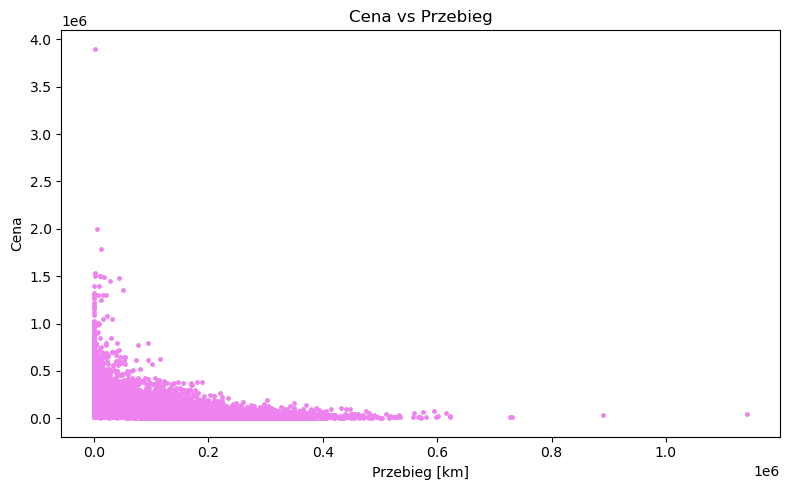

In [15]:
pdf_scatter = price_mileage.sample(fraction=0.1, seed=111).toPandas()

plt.figure(figsize=(8,5))
plt.scatter(pdf_scatter["mileage_km"], pdf_scatter["price_num"], s=6, color='violet')
plt.title("Cena vs Przebieg")
plt.xlabel("Przebieg [km]")
plt.ylabel("Cena")
plt.tight_layout()
plt.savefig("scatter_price_mileage.png")

print("Wizualizacja scatter zapisana jako scatter_price_mileage.png")

**Teoria:** `toPandas()` to akcja, która zbiera (collect) wszystkie dane na partycjach roboczych i przesyła je na węzeł główny (Driver), konwertując do struktury Pandas DataFrame. Uwaga: Można tego używać tylko na małych zbiorach (po limitowaniu np. top 10), w przeciwnym razie braknie pamięci RAM na Driverze!


---
# Zadanie samodzielne: Analiza Przestępczości w Chicago

Poniżej znajduje się miejsce na realizację zadania z analizy danych przy użyciu PySpark na zbiorze *Chicago Crimes* (około 50 000 ostatnich zdarzeń). Twoim celem jest przygotowanie, wyczyszczenie oraz zanalizowanie tych danych z wykorzystaniem zaawansowanych optymalizacji dostępnych w Sparku.

### Wymagania:
1. **Wczytanie i Czyszczenie Danych:** Wczytaj pobrany plik `chicago_crimes_sample.csv`. Usuń ewentualne duplikaty, wiersze z brakami danych (szczególnie w kluczowych kolumnach) i odfiltruj/napraw błędne daty.
2. **UDF i Pora Dnia:** Dodaj nową kolumnę z klasyfikacją pory dnia (np. noc, dzień, wieczór) utworzoną za pomocą User Defined Function (UDF) w oparciu o godzinę z kolumny `Date`.
3. **Optymalizacja i Partycjonowanie:** Zoptymalizuj przetwarzanie. Zastanów się, w których momentach użyć `cache()`. Przy dołączaniu mniejszych tabel słownikowych (jeśli byś je tworzył), wykorzystaj *broadcast join*. Ostatecznie zapisz przefiltrowane dane do formatu **Parquet** z podziałem na partycje według roku (`Year`).
4. **Analiza i Plany Zapytań:** Przeprowadź analizę statystyczną przestępstw (np. jakiego typu przestępstwa są najpopularniejsze w konkretnych lokacjach, o konkretnym czasie). Wykorzystaj funkcję `.explain()` aby udokumentować plan zapytania Sparka dla najcięższej agregacji.
5. *(Opcjonalnie)* **Uczenie Maszynowe (MLlib):** Spróbuj zbudować i wytrenować prosty model wieloklasowy, przewidujący rodzaj przestępstwa (`Primary Type`) na podstawie innych atrybutów, jak lokacja, godzina, arrest itp.

In [16]:
# Tutaj wpisz swój kod zliczający, czytający plik itp.
# Podpowiedź krok 1:

df_crimes = spark.read.option("header", True).csv("chicago_crimes_sample.csv")
df_crimes.show(5)

+-------------+--------------+--------------------+--------------------+----+------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+--------------------+------------+-------------+--------+
|           id|   case_number|                date|               block|iucr|primary_type|         description|location_description|arrest|domestic|beat|district|ward|community_area|fbi_code|x_coordinate|y_coordinate|year|          updated_on|    latitude|    longitude|location|
+-------------+--------------+--------------------+--------------------+----+------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+--------------------+------------+-------------+--------+
|     14193193|      JK249780|2026-05-07T00:00:...|057XX S MASSASOIT...|0820|       THEFT|      $500 AND UNDER|              STREET| false|   false|0811|     00

In [17]:
df_crimes = df_crimes.withColumn("id",
                   F.regexp_replace(F.col("id"), r"[^\d]", "").cast("integer"))

df_crimes = df_crimes.withColumn("x_coordinate",
                   F.regexp_replace(F.col("x_coordinate"), r"[^\d]", "").cast("integer"))

df_crimes = df_crimes.withColumn("y_coordinate",
                   F.regexp_replace(F.col("y_coordinate"), r"[^\d]", "").cast("integer"))

df_crimes = df_crimes.withColumn("latitude",
                   F.regexp_replace(F.col("latitude"), r"[^\d]", "").cast("double"))

df_crimes = df_crimes.withColumn("longitude",
                   F.regexp_replace(F.col("longitude"), r"[^\d]", "").cast("double"))

df_crimes = df_crimes.withColumn("date", F.col("date").cast("timestamp"))

df_crimes = df_crimes.na.drop(subset=['id', 'case_number', 'x_coordinate', 'y_coordinate', 'longitude', 'latitude'])
df_crimes = df_crimes.dropDuplicates()

years = df_crimes.groupBy('year').count() #poprawne

df_crimes = df_crimes.withColumn("date_parsed", F.to_timestamp("date"))
invalid_dates = df_crimes.filter(F.col("date_parsed").isNull()) # poprawne
df_crimes = df_crimes.withColumn("date_parsed", F.to_timestamp("updated_on"))
invalid_dates = df_crimes.filter(F.col("date_parsed").isNull()) # poprawne

df_crimes.show(5)

+--------+-----------+-------------------+--------------------+----+---------------+--------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+--------------------+---------------+---------------+--------+-------------------+
|      id|case_number|               date|               block|iucr|   primary_type|   description|location_description|arrest|domestic|beat|district|ward|community_area|fbi_code|x_coordinate|y_coordinate|year|          updated_on|       latitude|      longitude|location|        date_parsed|
+--------+-----------+-------------------+--------------------+----+---------------+--------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+--------------------+---------------+---------------+--------+-------------------+
|14189699|   JK245459|2026-05-06 18:15:00|052XX N WINTHROP AVE|1320|CRIMINAL DAMAGE|    TO VEHICLE|              STREET| 

In [18]:
from pyspark.sql.functions import udf, PandasUDFType
from pyspark.sql.types import StringType

@udf(returnType=StringType())
def part_of_day(date):
    if date.hour < 10:
        part = 'Morning'
    elif date.hour <= 12:
        part = 'Noon'
    elif date.hour < 18:
        part = 'Afternoon'
    else:
        part = 'Night'
    
    return part
    
df_crimes = df_crimes.withColumn(
    "part_of_day",
    part_of_day(F.col("date"))
)

df_crimes.show(3)

+--------+-----------+-------------------+--------------------+----+---------------+-----------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+--------------------+---------------+---------------+--------+-------------------+-----------+
|      id|case_number|               date|               block|iucr|   primary_type|description|location_description|arrest|domestic|beat|district|ward|community_area|fbi_code|x_coordinate|y_coordinate|year|          updated_on|       latitude|      longitude|location|        date_parsed|part_of_day|
+--------+-----------+-------------------+--------------------+----+---------------+-----------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+--------------------+---------------+---------------+--------+-------------------+-----------+
|14189699|   JK245459|2026-05-06 18:15:00|052XX N WINTHROP AVE|1320|CRIMINAL DAMAGE| TO VEHICL

3. **Optymalizacja i Partycjonowanie:** Zoptymalizuj przetwarzanie. Zastanów się, w których momentach użyć `cache()`. Przy dołączaniu mniejszych tabel słownikowych (jeśli byś je tworzył), wykorzystaj *broadcast join*. Ostatecznie zapisz przefiltrowane dane do formatu **Parquet** z podziałem na partycje według roku (`Year`).


In [19]:
df = df_crimes.withColumn("Year", F.year("date"))

df = df.withColumn(
    "part_of_day",
    part_of_day(F.col("date"))
)

df = df.cache()

# broadcast join gdyby był

df.write \
  .mode("overwrite") \
  .partitionBy("Year") \
  .parquet("output/crimes_parquet")

26/05/18 09:46:07 WARN MemoryManager: Total allocation exceeds 95,00% (1 020 054 720 bytes) of heap memory
Scaling row group sizes to 95,00% for 8 writers


4. **Analiza i Plany Zapytań:** Przeprowadź analizę statystyczną przestępstw (np. jakiego typu przestępstwa są najpopularniejsze w konkretnych lokacjach, o konkretnym czasie). Wykorzystaj funkcję `.explain()` aby udokumentować plan zapytania Sparka dla najcięższej agregacji.


In [20]:
df_crimes.show(5)

+--------+-----------+-------------------+--------------------+----+---------------+--------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+--------------------+---------------+---------------+--------+-------------------+-----------+
|      id|case_number|               date|               block|iucr|   primary_type|   description|location_description|arrest|domestic|beat|district|ward|community_area|fbi_code|x_coordinate|y_coordinate|year|          updated_on|       latitude|      longitude|location|        date_parsed|part_of_day|
+--------+-----------+-------------------+--------------------+----+---------------+--------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+--------------------+---------------+---------------+--------+-------------------+-----------+
|14189699|   JK245459|2026-05-06 18:15:00|052XX N WINTHROP AVE|1320|CRIMINAL DAMAGE| 

In [21]:
type_crime = df_crimes.groupBy('primary_type') \
    .count().orderBy(F.col('count').desc())
type_crime.show(5)

+-------------------+-----+
|       primary_type|count|
+-------------------+-----+
|              THEFT|10895|
|            BATTERY| 9250|
|    CRIMINAL DAMAGE| 5493|
|            ASSAULT| 4561|
|MOTOR VEHICLE THEFT| 3882|
+-------------------+-----+
only showing top 5 rows



In [22]:
df_crimes = df_crimes.withColumn(
    'day_of_week',
    F.date_format(F.col('date'), 'EEEE')
)

df_day = df_crimes.groupBy('day_of_week').count().orderBy(F.col('count').desc())
df_day.show()

+-----------+-----+
|day_of_week|count|
+-----------+-----+
|  Wednesday| 7348|
|   Saturday| 7314|
|     Monday| 7225|
|    Tuesday| 7146|
|     Friday| 7077|
|     Sunday| 7032|
|   Thursday| 6782|
+-----------+-----+



In [23]:
heavy_aggregation = (
    df_crimes
    .groupBy(
        "location_description",
        "primary_type",
        "part_of_day"
    )
    .agg(
        F.count("*").alias("crime_count")
    )
    .orderBy(F.desc("crime_count"))
)

heavy_aggregation.show(20, truncate=False)

+--------------------+-------------------+-----------+-----------+
|location_description|primary_type       |part_of_day|crime_count|
+--------------------+-------------------+-----------+-----------+
|STREET              |MOTOR VEHICLE THEFT|Night      |1151       |
|APARTMENT           |BATTERY            |Morning    |1095       |
|STREET              |MOTOR VEHICLE THEFT|Morning    |1030       |
|APARTMENT           |BATTERY            |Night      |943        |
|STREET              |CRIMINAL DAMAGE    |Morning    |907        |
|STREET              |THEFT              |Morning    |862        |
|STREET              |THEFT              |Night      |698        |
|STREET              |CRIMINAL DAMAGE    |Night      |665        |
|STREET              |BURGLARY           |Morning    |623        |
|APARTMENT           |BATTERY            |Afternoon  |616        |
|STREET              |BURGLARY           |Night      |543        |
|STREET              |MOTOR VEHICLE THEFT|Afternoon  |541     

In [24]:
heavy_aggregation.explain(True)

== Parsed Logical Plan ==
'Sort ['crime_count DESC NULLS LAST], true
+- Aggregate [location_description#5649, primary_type#5647, part_of_day#6148], [location_description#5649, primary_type#5647, part_of_day#6148, count(1) AS crime_count#7286L]
   +- Project [id#5798, case_number#5643, date#5913, block#5645, iucr#5646, primary_type#5647, description#5648, location_description#5649, arrest#5650, domestic#5651, beat#5652, district#5653, ward#5654, community_area#5655, fbi_code#5656, x_coordinate#5821, y_coordinate#5844, year#5659, updated_on#5660, latitude#5867, longitude#5890, location#5663, date_parsed#6008, part_of_day#6148, date_format(date#5913, EEEE, Some(Europe/Warsaw)) AS day_of_week#7172]
      +- Project [id#5798, case_number#5643, date#5913, block#5645, iucr#5646, primary_type#5647, description#5648, location_description#5649, arrest#5650, domestic#5651, beat#5652, district#5653, ward#5654, community_area#5655, fbi_code#5656, x_coordinate#5821, y_coordinate#5844, year#5659, upd

5. *(Opcjonalnie)* **Uczenie Maszynowe (MLlib):** Spróbuj zbudować i wytrenować prosty model wieloklasowy, przewidujący rodzaj przestępstwa (`Primary Type`) na podstawie innych atrybutów, jak lokacja, godzina, arrest itp.

In [25]:
df_ml = (
    df_crimes
    .withColumn("hour", F.hour("date"))
    .withColumn(
        "day_of_week",
        F.dayofweek("date")
    )
    .withColumn(
        "arrest",
        F.when(F.col("arrest") == "true", 1).otherwise(0)
    )
    .withColumn(
        "domestic",
        F.when(F.col("domestic") == "true", 1).otherwise(0)
    )
)

df_ml = df_ml.select(
    "primary_type",
    "location_description",
    "hour",
    "day_of_week",
    "arrest",
    "domestic"
).dropna()

In [26]:
from pyspark.ml.feature import StringIndexer

location_indexer = StringIndexer(
    inputCol="location_description",
    outputCol="location_idx",
    handleInvalid="keep"
)

label_indexer = StringIndexer(
    inputCol="primary_type",
    outputCol="label",
    handleInvalid="keep"
)

In [27]:
from pyspark.ml.feature import VectorAssembler

# modele w Spark MLlib potrzebuja wszystkich cech wejściowych w jednej kolumnie typu wektorowego
assembler = VectorAssembler(
    inputCols=[
        "location_idx",
        "hour",
        "day_of_week",
        "arrest",
        "domestic"
    ],
    outputCol="features"
)

In [28]:
from pyspark.ml.classification import RandomForestClassifier

train_df, test_df = df_ml.randomSplit([0.8, 0.2], seed=111)

rf = RandomForestClassifier(
    labelCol="label",
    featuresCol="features",
    numTrees=50,
    maxBins=150
)

In [29]:
from pyspark.ml import Pipeline

pipeline = Pipeline(stages=[
    label_indexer,
    location_indexer,
    assembler,
    rf
])

model = pipeline.fit(train_df)

26/05/18 09:46:27 WARN DAGScheduler: Broadcasting large task binary with size 1067.4 KiB


In [30]:
predictions = model.transform(test_df)

predictions.select(
    "primary_type",
    "prediction",
    "probability"
).show(10, truncate=False)

+------------+----------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|primary_type|prediction|probability                                                                                                                                                                                                                                                                                                                 

26/05/18 09:46:30 WARN DAGScheduler: Broadcasting large task binary with size 1042.5 KiB


In [31]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

accuracy = evaluator.evaluate(predictions)

print(f"Accuracy: {accuracy:.4f}")

26/05/18 09:46:31 WARN DAGScheduler: Broadcasting large task binary with size 1054.2 KiB


Accuracy: 0.3343
